
### Car Market Analysis
### Dataset Source: Kaggle Car Features and MSRP Dataset
#### Student: 25001700


# Import libraries
I have imported libraries as numpy for numerical operations, pandas for data manipulation, matplotlib and seaborn for visualisations.



In [2]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

## Import the csv file and checking the description, information of data


In [3]:
# Import the csv file and checking the description, information of data

df = pd.read_csv("data.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11914 entries, 0 to 11913
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Make               11914 non-null  object 
 1   Model              11914 non-null  object 
 2   Year               11914 non-null  int64  
 3   Engine Fuel Type   11911 non-null  object 
 4   Engine HP          11845 non-null  float64
 5   Engine Cylinders   11884 non-null  float64
 6   Transmission Type  11914 non-null  object 
 7   Driven_Wheels      11914 non-null  object 
 8   Number of Doors    11908 non-null  float64
 9   Market Category    8172 non-null   object 
 10  Vehicle Size       11914 non-null  object 
 11  Vehicle Style      11914 non-null  object 
 12  highway MPG        11914 non-null  int64  
 13  city mpg           11914 non-null  int64  
 14  Popularity         11914 non-null  int64  
 15  MSRP               11914 non-null  int64  
dtypes: float64(3), int64(5

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


# Data Pre-process

## Identifying missing values

In [4]:
# Identifying missing values
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Duplicated rows ===")
print(df.duplicated().sum())
print("\n=== Handling missing values and duplicates ===")
print(df.isnull().sum())
print("\n=== Dropping duplicates and missing values ===")
df = df.drop_duplicates()
print("\n=== After dropping duplicates ===")
df = df.dropna()


=== Missing values ===
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

=== Duplicated rows ===
715

=== Handling missing values and duplicates ===
Make                    0
Model                   0
Year                    0
Engine Fuel Type        3
Engine HP              69
Engine Cylinders       30
Transmission Type       0
Driven_Wheels           0
Number of Doors         6
Market Category      3742
Vehicle Size            0
Vehicle Style           0
highway MPG             0
city mpg                0
Popularity              0
MSRP                    0
dtype: int64

=== Dropping duplicates and missing valu

## Handling missing values
In this section, we identify and handle missing values in the dataset.
We'll check for null values and duplicates, then apply necessary cleaning methods.

In [ ]:
# Data Cleaning and Preprocessing
# 1. Handling Missing values
print("Missing values per column:")
print(df.isnull().sum())

# Duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())


# Create a working copy
df_clean = df.copy()

# Identify numeric and categorical columns
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
categorical_cols = df_clean.select_dtypes(include=['object']).columns

# Fill numeric missing values with median
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(
    df_clean[numeric_cols].median()
)

# Fill categorical missing values with 'Unknown'
df_clean[categorical_cols] = df_clean[categorical_cols].fillna('Unknown')

#  Remove duplicates
initial_count = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = initial_count - len(df_clean)

# Remove unwanted characters
df_clean['Market Category'] = df_clean['Market Category'].str.replace('"', '', regex=False)

# Standardize categorical text
text_columns = [
    'Make', 'Model', 'Engine Fuel Type', 'Transmission Type',
    'Driven_Wheels', 'Market Category', 'Vehicle Size', 'Vehicle Style'
]

for col in text_columns:
    df_clean[col] = df_clean[col].str.strip().str.title()

# Average fuel efficiency
df_clean['Avg MPG'] = (df_clean['highway MPG'] + df_clean['city mpg']) / 2

# Price category segmentation
df_clean['Price_Category'] = pd.cut(
    df_clean['MSRP'],
    bins=[0, 30000, 60000, 100000, float('inf')],
    labels=['Budget', 'Mid-Range', 'Premium', 'Luxury']
)

def remove_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[column] >= lower) & (data[column] <= upper)]

# Apply outlier removal
df_clean = remove_outliers_iqr(df_clean, 'MSRP')
df_clean = remove_outliers_iqr(df_clean, 'Engine HP')

print("Final dataset shape:", df_clean.shape)
print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

df_clean.head()



Cleaned shape: (7735, 16)

Data types:
Make                  object
Model                 object
Year                   int64
Engine Fuel Type      object
Engine HP            float64
Engine Cylinders     float64
Transmission Type     object
Driven_Wheels         object
Number of Doors      float64
Market Category       object
Vehicle Size          object
Vehicle Style         object
highway MPG            int64
city mpg               int64
Popularity             int64
MSRP                   int64
dtype: object

Cleaned shape: (6871, 18)

Data types:
Make                   object
Model                  object
Year                    int64
Engine Fuel Type       object
Engine HP             float64
Engine Cylinders      float64
Transmission Type      object
Driven_Wheels          object
Number of Doors       float64
Market Category        object
Vehicle Size           object
Vehicle Style          object
highway MPG             int64
city mpg                int64
Popularity            

## Importing the cleaned dataset

In [6]:
# Importing the cleaned dataset
df = pd.read_csv('cleaned_data.csv')

print("=" * 50)
print("CAR DATA ANALYSIS")
print("=" * 50)
# Show what we're working with
print("\nDATASET OVERVIEW")
print("-" * 30)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumns: {', '.join(df.columns)}")
print("\nSample data:")
df.head(3)

CAR DATA ANALYSIS

DATASET OVERVIEW
------------------------------
Rows: 10,177
Columns: 18

Columns: Make, Model, Year, Engine Fuel Type, Engine HP, Engine Cylinders, Transmission Type, Driven_Wheels, Number of Doors, Market Category, Vehicle Size, Vehicle Style, highway MPG, city mpg, Popularity, MSRP, Avg MPG, Price_Category

Sample data:


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP,Avg MPG,Price_Category
0,Bmw,1 Series M,2011,Premium Unleaded (Required),335.0,6.0,Manual,Rear Wheel Drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135,22.5,Mid-Range
1,Bmw,1 Series,2011,Premium Unleaded (Required),300.0,6.0,Manual,Rear Wheel Drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650,23.5,Mid-Range
2,Bmw,1 Series,2011,Premium Unleaded (Required),300.0,6.0,Manual,Rear Wheel Drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350,24.0,Mid-Range


# Visualisations of a simple dashboard of the car market overview
### Figure 1: Car Market Overview Dashboard
Four-panel dashboard showing key market metrics.\
(A) Cars per year trend,\
(B) Price distribution, \
(C) Top 10 brands by volume, \
(D) Scatter plot of Engine HP vs Highway MPG

CAR DATA ANALYSIS

DATASET OVERVIEW
------------------------------
Rows: 10,177
Columns: 18

Columns: Make, Model, Year, Engine Fuel Type, Engine HP, Engine Cylinders, Transmission Type, Driven_Wheels, Number of Doors, Market Category, Vehicle Size, Vehicle Style, highway MPG, city mpg, Popularity, MSRP, Avg MPG, Price_Category

Sample data:


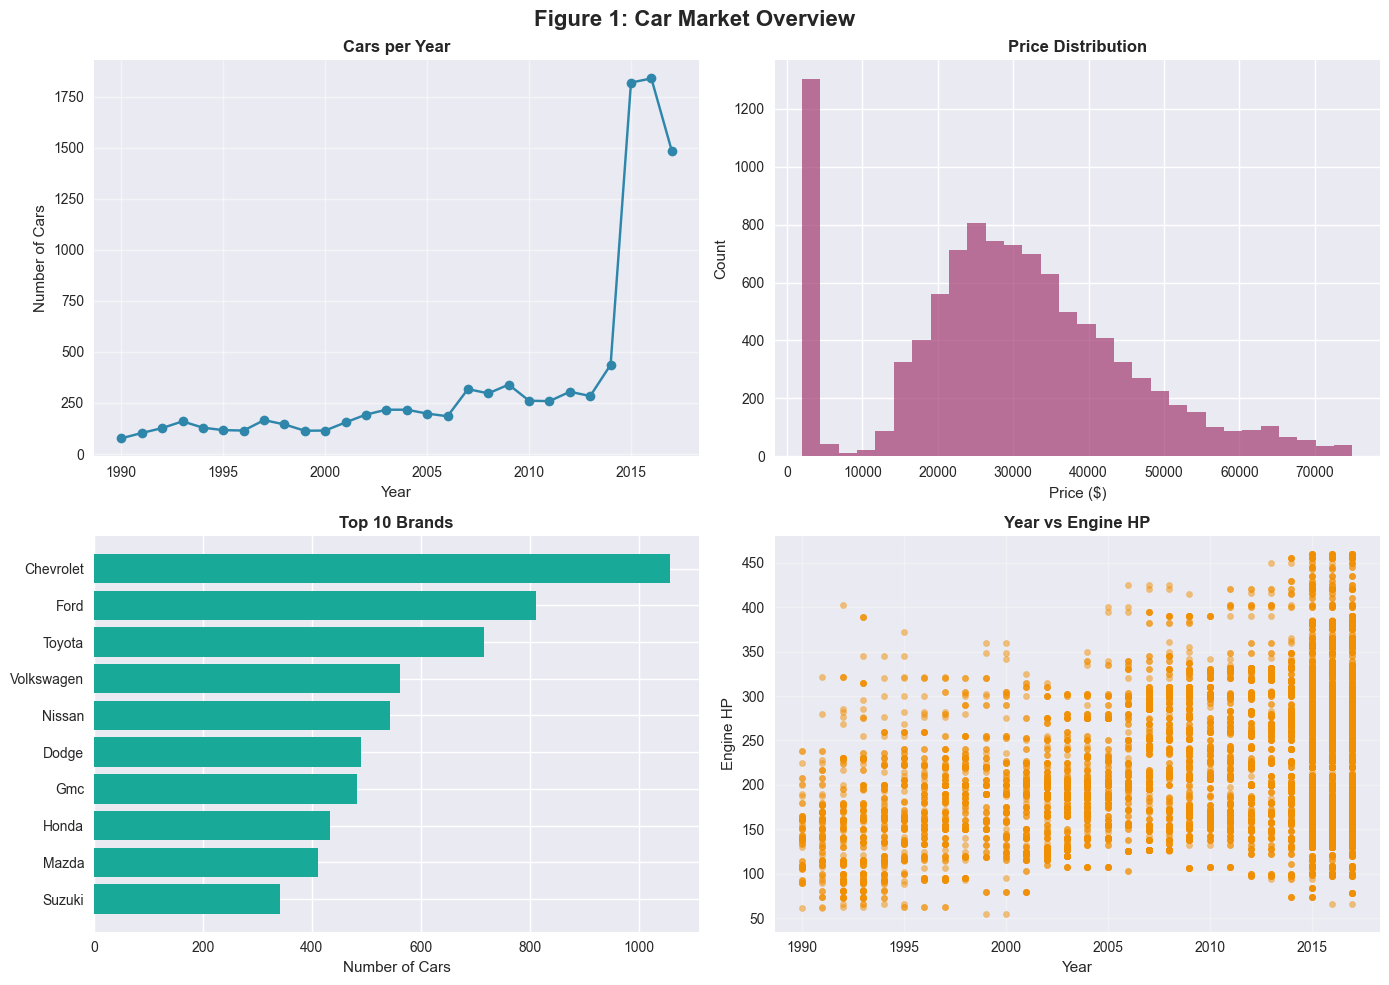

In [7]:
print("=" * 50)
print("CAR DATA ANALYSIS")
print("=" * 50)
# Show what we're working with
print("\nDATASET OVERVIEW")
print("-" * 30)
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nColumns: {', '.join(df.columns)}")
print("\nSample data:")
df.head(3)
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# simple dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Figure 1: Car Market Overview', fontsize=16, fontweight='bold')

# 1. Price trend over years
year_data = df.groupby('Year').size()
axes[0,0].plot(year_data.index, year_data.values, 'o-', color='#2E86AB')
axes[0,0].set_title('Cars per Year', fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Cars')
axes[0,0].grid(True, alpha=0.5)

# 2. Price distribution
price_columns = [col for col in df.columns if 'price' in col.lower() or 'msrp' in col.lower()]

price_col = price_columns[0]
prices = df[price_col].dropna()
axes[0,1].hist(prices, bins=30, color='#A23B72', alpha=0.7)
axes[0,1].set_title('Price Distribution', fontweight='bold')
axes[0,1].set_xlabel('Price ($)')
axes[0,1].set_ylabel('Count')

# 3. Top brands/makes
brand_columns = [col for col in df.columns if any(word in col.lower() for word in ['make', 'brand', 'manufacturer'])]
brand_col = brand_columns[0]
top_brands = df[brand_col].value_counts().head(10)
bars = axes[1,0].barh(range(len(top_brands)), top_brands.values, color='#18A999')
axes[1,0].set_yticks(range(len(top_brands)))
axes[1,0].set_yticklabels(top_brands.index)
axes[1,0].set_title('Top 10 Brands', fontweight='bold')
axes[1,0].set_xlabel('Number of Cars')
axes[1,0].invert_yaxis()

# 4. Simple scatter if we have numeric data
numeric_cols = df.select_dtypes(include=[np.number]).columns
col1, col2 = numeric_cols[0], numeric_cols[1]
axes[1,1].scatter(df[col1], df[col2], alpha=0.5, s=20, color='#F18F01')
axes[1,1].set_title(f'{col1} vs {col2}', fontweight='bold')
axes[1,1].set_xlabel(col1)
axes[1,1].set_ylabel(col2)
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



#  Visualisations

## Car price distribution Barchart
### Figure 2: Price Distribution with Statistical Measures
*Histogram showing the distribution of car prices with mean (red dashed line) 
and median (green dashed line) marked for comparison.*


PRICE ANALYSIS
--------------------
Average price: $29,345
Median price: $29,065
Price range: $2,000 - $75,000


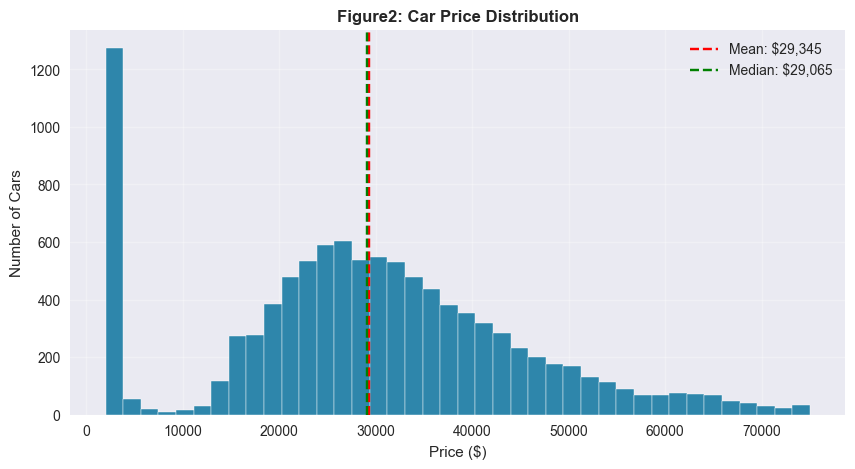

In [8]:
# Redefine column lists
from matplotlib import pyplot as plt


price_columns = [col for col in df.columns if 'price' in col.lower() or 'msrp' in col.lower()]
brand_columns = [col for col in df.columns if any(word in col.lower() for word in ['make', 'brand', 'manufacturer'])]
numeric_cols = df.select_dtypes(include=[np.number]).columns


# Price analysis
if price_columns:
    price_col = price_columns[0]
    prices = df[price_col].dropna()
    
    print(f"\nPRICE ANALYSIS")
    print("-" * 20)
    print(f"Average price: ${prices.mean():,.0f}")
    print(f"Median price: ${prices.median():,.0f}")
    print(f"Price range: ${prices.min():,.0f} - ${prices.max():,.0f}")
    
    # Price distribution chart
    plt.figure(figsize=(10, 5))
    plt.hist(prices, bins=40, color='#2E86AB', edgecolor='white')
    plt.axvline(prices.mean(), color='red', linestyle='--', label=f'Mean: ${prices.mean():,.0f}')
    plt.axvline(prices.median(), color='green', linestyle='--', label=f'Median: ${prices.median():,.0f}')
    plt.title('Figure2: Car Price Distribution', fontweight='bold')
    plt.xlabel('Price ($)')
    plt.ylabel('Number of Cars')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()





## Brand Analysis bar chart
### Figure 3: Average Price by Brand (Top 10)
*Horizontal bar chart comparing average prices across the top 10 most common 
car brands in the dataset.*


BRAND ANALYSIS
--------------------
Total unique brands: 39

Top 5 most common brands:
  1. Chevrolet: 1058 cars
  2. Ford: 812 cars
  3. Toyota: 716 cars
  4. Volkswagen: 562 cars
  5. Nissan: 543 cars


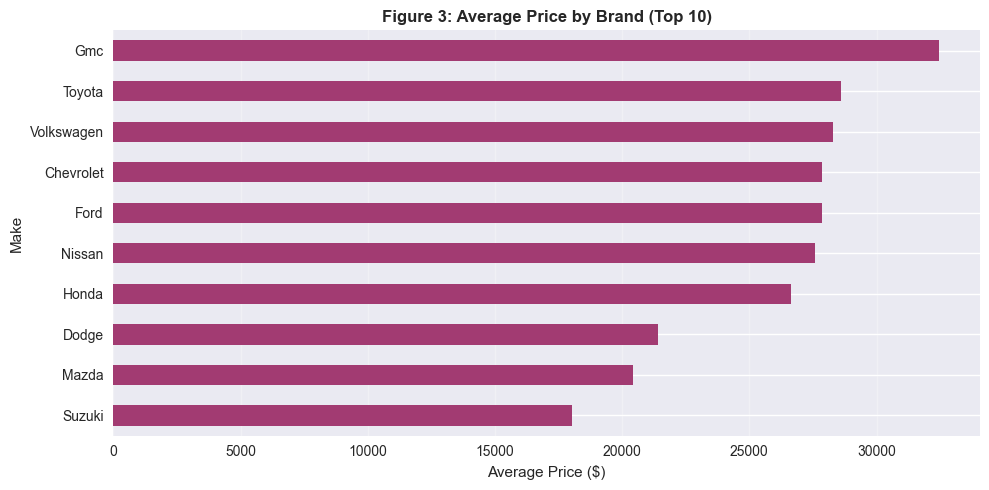

In [9]:
# Brand analysis
if brand_columns:
    brand_col = brand_columns[0]
    brand_counts = df[brand_col].value_counts()
    
    print(f"\nBRAND ANALYSIS")
    print("-" * 20)
    print(f"Total unique brands: {len(brand_counts)}")
    print(f"\nTop 5 most common brands:")
    for i, (brand, count) in enumerate(brand_counts.head().items(), 1):
        print(f"  {i}. {brand}: {count} cars")
    
    if price_columns:
        # Average price by brand
        top_10_brands = brand_counts.head(10).index
        brand_prices = df[df[brand_col].isin(top_10_brands)].groupby(brand_col)[price_col].mean()
        
        plt.figure(figsize=(10, 5))
        brand_prices.sort_values().plot(kind='barh', color='#A23B72')
        plt.title('Figure 3: Average Price by Brand (Top 10)', fontweight='bold')
        plt.xlabel('Average Price ($)')
        plt.grid(True, alpha=0.3, axis='x')
        plt.tight_layout()
        plt.show()

## Correlation Matrix 
### Figure 4: Feature Correlation Heatmap
*Heatmap showing Pearson correlation coefficients between the top 5 numerical 
features in the dataset. Color intensity represents correlation strength.*


QUICK CORRELATIONS
--------------------


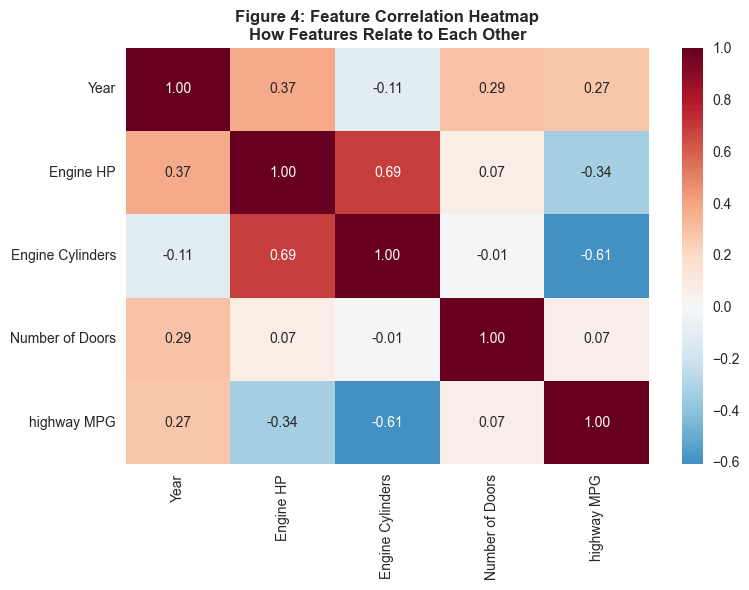

In [10]:
# Simple correlation
if len(numeric_cols) >= 3:
    print(f"\nQUICK CORRELATIONS")
    print("-" * 20)
    
    # Get top 5 numeric columns
    top_num_cols = numeric_cols[:5]
    corr_matrix = df[top_num_cols].corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
    plt.title('Figure 4: Feature Correlation Heatmap\nHow Features Relate to Each Other', fontweight='bold')
    plt.tight_layout()
    plt.show()

# summary 

In [11]:
# Summary
print("\n" + "=" * 50)
print("ANALYSIS COMPLETE")
print("=" * 50)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
price_columns = [col for col in df.columns if 'price' in col.lower() or 'msrp' in col.lower()]
brand_columns = [col for col in df.columns if 'make' in col.lower() or 'brand' in col.lower()]

print(f"\nSummary:")
print(f"   • Analyzed {len(df):,} cars")
print(f"   • Found {len(df.columns)} data points per car")
print(f"   • {len(numeric_cols)} numeric features")
print(f"   • {len(df.select_dtypes('object').columns)} categorical features")


print("\nAll charts displayed above.")


ANALYSIS COMPLETE

Summary:
   • Analyzed 10,177 cars
   • Found 18 data points per car
   • 9 numeric features
   • 9 categorical features

All charts displayed above.


# Statistics summary

In [12]:


print("🚗 CAR DATASET INSIGHTS")
print("=" * 50)

# 1. Quick Overview
print(f"\n📊 Overview:")
print(f"• {len(df):,} cars | {df['Year'].min()}-{df['Year'].max()}")
print(f"• {df['Make'].nunique():,} brands | {df['Model'].nunique():,} models")
print(f"• Average price: ${df['MSRP'].mean():,.0f}")

# 2. Price Snapshot
p = df['MSRP']
print(f"\n💰 Price Range:")
print(f"• ${p.min():,.0f} → ${p.max():,.0f}")
print(f"• 50% under ${p.median():,.0f}")
print(f"• Top 1%: above ${p.quantile(0.99):,.0f}")

# 3. Performance Stats
print(f"\n⚡ Performance:")
print(f"• Avg power: {df['Engine HP'].mean():.0f} HP")
print(f"• Max power: {df['Engine HP'].max():.0f} HP")
print(f"• Avg cylinders: {df['Engine Cylinders'].mean():.1f}")

# 4. Efficiency
print(f"\n⛽ Fuel Efficiency:")
print(f"• City: {df['city mpg'].mean():.1f} MPG")
print(f"• Highway: {df['highway MPG'].mean():.1f} MPG")
print(f"• Best overall: {df['Avg MPG'].max():.1f} MPG")

# 5. Top Brands
print(f"\n🏆 Top 5 Brands:")
for brand, count in df['Make'].value_counts().head(5).items():
    print(f"• {brand}: {count:,} cars ({(count/len(df)*100):.1f}%)")

# 6. Standout Cars
print(f"\n🌟 Standout Cars:")
print(f"• Most expensive: {df.loc[df['MSRP'].idxmax(), 'Make']} (${df['MSRP'].max():,.0f})")
print(f"• Most powerful: {df.loc[df['Engine HP'].idxmax(), 'Make']} ({df['Engine HP'].max():.0f} HP)")
print(f"• Best MPG: {df.loc[df['Avg MPG'].idxmax(), 'Make']} ({df['Avg MPG'].max():.1f} MPG)")

# 7. Correlations (Simple)
print(f"\n📈 Key Relationships:")
corr = df[['MSRP', 'Engine HP', 'Year', 'Avg MPG']].corr()
print(f"• Price ↔ Horsepower: {corr.loc['MSRP', 'Engine HP']:.2f}")
print(f"• Horsepower ↔ MPG: {corr.loc['Engine HP', 'Avg MPG']:.2f}")

# 8. Data Health
print(f"\n✅ Data Quality:")
print(f"• Missing values: {df.isnull().sum().sum()}")
print(f"• Duplicates: {df.duplicated().sum()}")

print("\n" + "=" * 50)

🚗 CAR DATASET INSIGHTS

📊 Overview:
• 10,177 cars | 1990-2017
• 39 brands | 785 models
• Average price: $29,345

💰 Price Range:
• $2,000 → $75,000
• 50% under $29,065
• Top 1%: above $68,935

⚡ Performance:
• Avg power: 230 HP
• Max power: 460 HP
• Avg cylinders: 5.4

⛽ Fuel Efficiency:
• City: 20.2 MPG
• Highway: 27.1 MPG
• Best overall: 189.0 MPG

🏆 Top 5 Brands:
• Chevrolet: 1,058 cars (10.4%)
• Ford: 812 cars (8.0%)
• Toyota: 716 cars (7.0%)
• Volkswagen: 562 cars (5.5%)
• Nissan: 543 cars (5.3%)

🌟 Standout Cars:
• Most expensive: Tesla ($75,000)
• Most powerful: Chevrolet (460 HP)
• Best MPG: Audi (189.0 MPG)

📈 Key Relationships:
• Price ↔ Horsepower: 0.73
• Horsepower ↔ MPG: -0.35

✅ Data Quality:
• Missing values: 0
• Duplicates: 0



## Data Source
This analysis uses the "Car Features and MSRP" dataset from Kaggle.

CooperUnion (2016) Car features and MSRP, Kaggle. Available at: https://www.kaggle.com/datasets/CooperUnion/cardataset (Accessed: 11 December 2025). 